# ACF-MAAR: Autocorrelation-Guided Multi-Window and AutoML-based Adaptable Regression

## Leveraging Autocorrelation for Adaptive Multi-Window based Regression in Streaming Data

**Authors:** Shahad Palathingal and Ebin Deni Raj  
**Affiliation:** Department of CSE, Indian Institute of Information Technology, Kottayam, Kerala, India

---# ACF-MAAR: Elec2 Australian Electricity Market Evaluation

## Cross-Dataset Validation — Australian NSW Electricity Market

**Dataset:** 45,312 observations at 30-minute intervals
**Target:** nswdemand (NSW electricity demand, normalized 0–1)
**Source:** [OpenML / Kaggle](https://www.kaggle.com/datasets/yashsharan/the-elec2-dataset)



---
## 1. Environment Setup & Imports

> **Important:** Run **Cell 1a** → **Runtime → Restart session** → Run **Cell 1b, 1c, 1d** in order.

In [1]:
# ===== Cell 1a: INSTALL PACKAGES =====
# Run this cell ONCE, then restart runtime (Runtime → Restart session)

!pip install pycaret==3.3.2 --no-deps --quiet
!pip install river==0.21.2 --no-deps --quiet
!pip install shap==0.46.0 --no-deps --quiet
!pip install scikit-plot --quiet
!pip install -q imbalanced-learn ipywidgets cloudpickle deprecation xxhash category_encoders databricks-sdk

print("✓ All packages installed.")
print("⚠ NOW: Go to Runtime → Restart session, then run Cell 1b.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.1/486.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.9/543.9 kB 5.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pycaret 3.3.2 requires category-encoders>=2.4.0, which is not installed.
pycaret 3.3.2 requires kaleido>=0.2.1, which is not installed.
pycaret 3.3.2 requires plotly-resampler>=0.8.3.1, which is not installed.
pycaret 3.3.2 requires pmdarima>=2.0.4, which is not installed.
pycaret 3.3.2 requires pyod>=1.1.3, which is not installed.
pycaret 3.3.2 requires schemdraw==0.15, which is not installed.
pycaret 3.3.2 requires sktime==0.26.0, which is not installed.
pycaret 3.3.2 requires tbats>=1.1.3, which is not installed.
pycaret 3.3.2 requires wurlitzer; platform_system != "Windows", wh

In [1]:
# ===== Cell 1b: PATCH COMPATIBILITY ISSUES =====
# Run this AFTER restarting the runtime

import site, os, glob

# --- Patch 1: Fix PyCaret version check ---
pycaret_init = os.path.join(site.getsitepackages()[0], 'pycaret', '__init__.py')
with open(pycaret_init, 'w') as f:
    f.write('''import sys
from pycaret.utils._show_versions import show_versions
version_ = "3.3.2"
__version__ = version_
__all__ = ["show_versions", "__version__"]
''')
print("✓ Patch 1/5: PyCaret version check removed.")

# --- Patch 2: Fix PyCaret memory.py ---
memory_path = os.path.join(site.getsitepackages()[0], 'pycaret', 'internal', 'memory.py')
with open(memory_path, 'r') as f:
    content = f.read()
if 'FastMemory' in content:
    content = content.replace(
        'return FastMemory(tmpdir, verbose=0, bytes_limit=DEFAULT_BYTES_LIMIT)',
        'return None'
    )
    content = content.replace(
        'return FastMemory(tmpdir, verbose=0)',
        'return None'
    )
    with open(memory_path, 'w') as f:
        f.write(content)
    print("✓ Patch 2/5: PyCaret memory.py — FastMemory disabled.")
else:
    print("✓ Patch 2/5: PyCaret memory.py already clean.")

# --- Patch 3: Fix pipeline.py _print_elapsed_time ---
pipeline_path = os.path.join(site.getsitepackages()[0], 'pycaret', 'internal', 'pipeline.py')
with open(pipeline_path, 'r') as f:
    content = f.read()
if 'from sklearn.utils import _print_elapsed_time' in content:
    content = content.replace(
        'from sklearn.utils import _print_elapsed_time',
        ''
    )
    anchor = "from pycaret.utils.generic import get_all_object_vars_and_properties, variable_return"
    replacement = anchor + """

from contextlib import contextmanager

@contextmanager
def _print_elapsed_time(source, message=None):
    yield"""
    content = content.replace(anchor, replacement)
    with open(pipeline_path, 'w') as f:
        f.write(content)
    print("✓ Patch 3/5: pipeline.py — _print_elapsed_time context manager injected.")
else:
    print("✓ Patch 3/5: pipeline.py already patched.")

# --- Patch 4: Fix scikitplot scipy.interp ---
scikitplot_dir = os.path.join(site.getsitepackages()[0], 'scikitplot')
fixed_files = []
for filepath in glob.glob(os.path.join(scikitplot_dir, '*.py')):
    with open(filepath, 'r') as f:
        content = f.read()
    if 'from scipy import interp' in content:
        content = content.replace('from scipy import interp', 'from numpy import interp')
        with open(filepath, 'w') as f:
            f.write(content)
        fixed_files.append(os.path.basename(filepath))
if fixed_files:
    print(f"✓ Patch 4/5: Fixed scikitplot files: {', '.join(fixed_files)}")
else:
    print("✓ Patch 4/5: scikitplot already clean.")

# --- Patch 5: Fix sklearn._print_elapsed_time for other imports ---
import sklearn.utils
import sys
from contextlib import contextmanager

@contextmanager
def _print_elapsed_time_cm(source, message=None):
    yield

sklearn.utils._print_elapsed_time = _print_elapsed_time_cm
sys.modules['sklearn.utils']._print_elapsed_time = _print_elapsed_time_cm
print("✓ Patch 5/5: sklearn._print_elapsed_time runtime patch applied.")

print()
print("✅ All patches applied. Now run Cell 1c (imports).")

✓ Patch 1/5: PyCaret version check removed.
✓ Patch 2/5: PyCaret memory.py — FastMemory disabled.
✓ Patch 3/5: pipeline.py — _print_elapsed_time context manager injected.
✓ Patch 4/5: Fixed scikitplot files: metrics.py, plotters.py
✓ Patch 5/5: sklearn._print_elapsed_time runtime patch applied.

✅ All patches applied. Now run Cell 1c (imports).


In [2]:
# ===== Cell 1c: IMPORTS =====
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['PYTHONWARNINGS'] = 'ignore'

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time
import threading

from sklearn.model_selection import cross_val_score, RepeatedKFold
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

from river import drift
from river.linear_model import LinearRegression
from river.optim import SGD
from river.metrics import MSE
from river.stream import iter_pandas

import jinja2
from pycaret.regression import setup, compare_models, pull, predict_model, finalize_model

from river.drift import PageHinkley, ADWIN, KSWIN

from datetime import datetime

from statsmodels.tsa.stattools import acf
from scipy.stats import chi2

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print("✅ All imports successful.")

✅ All imports successful.


In [3]:
# Mount Google Drive (Colab only)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## 2. Data Loading & Pre-processing

Load the **Elec2 (Australian NSW Electricity Market)** dataset.
The dataset contains 45,312 observations at 30-minute intervals. All values are normalized between 0 and 1.

**Target variable:** `nswdemand` (NSW electricity demand)
**Frequency:** 30 minutes → **48 samples per day**

In [4]:
# ===== DATASET CONFIGURATION =====
# All dataset-specific constants are defined here.
# To adapt this notebook to another dataset, modify ONLY this cell.

DATASET_NAME = "Elec2 — Australian Electricity Market"
DATA_PATH = "/content/drive/MyDrive/AFC_MAAR/Elect2.csv"
TARGET_COL = "nswdemand"
SAMPLING_INTERVAL = "30 min"
DAY_SIZE = 48            # 24h * 2 samples/hour = 48 samples per day
N_LAGS = 24              # Lag features (~12 hours lookback)
ERROR_THRESHOLD = 0.05   # Normalized scale (0–1), so threshold is small

print(f"Dataset: {DATASET_NAME}")
print(f"Target: {TARGET_COL}")
print(f"Sampling: {SAMPLING_INTERVAL} → {DAY_SIZE} samples/day")
print(f"Lag features: {N_LAGS}")

Dataset: Elec2 — Australian Electricity Market
Target: nswdemand
Sampling: 30 min → 48 samples/day
Lag features: 24


In [5]:
# --- Load dataset ---
df_raw = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")
print(f"Total days: {len(df_raw) // DAY_SIZE:.0f}")
df_raw.head()

Dataset shape: (45312, 5)
Columns: ['nswprice', 'nswdemand', 'vicprice', 'vicdemand', 'transfer']
Total days: 944


,nswprice,nswdemand,vicprice,vicdemand,transfer
0,0.056443,0.439155,0.003467,0.422915,0.414912
1,0.051699,0.415055,0.003467,0.422915,0.414912
2,0.051489,0.385004,0.003467,0.422915,0.414912
3,0.045485,0.314639,0.003467,0.422915,0.414912
4,0.042482,0.251116,0.003467,0.422915,0.414912


In [6]:
# --- Extract target variable ---
newdf = df_raw[[TARGET_COL]].copy()
newdf.columns = ['target']
print(f"Target series shape: {newdf.shape}")
print(f"\nBasic statistics:")
newdf.describe()

Target series shape: (45312, 1)

Basic statistics:


,target
count,45312.000000
mean,0.425418
std,0.163323
min,0.000000
25%,0.309134
50%,0.443693
75%,0.536001
max,1.000000


---
## 3. Feature Engineering (Supervised Framing)

Transform the univariate time series into a supervised learning problem using lagged features.

**Reference:** Section 3.1 (Preliminaries and Notation)

In [7]:
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    """
    Convert a time series to a supervised learning dataset.
    """
    n_vars = 1 if type(data) is list else data.shape[1]
    dff = pd.DataFrame(data)
    cols, names = list(), list()

    for i in range(n_in, 0, -1):
        cols.append(dff.shift(-i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]

    for i in range(0, n_out):
        cols.append(dff.shift(-i))
        if i == 0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]

    agg = pd.concat(cols, axis=1)
    agg.columns = names
    if dropnan:
        agg.dropna(inplace=True)
    return agg

In [8]:
# --- Create supervised dataset ---
reframed = series_to_supervised(newdf.values, N_LAGS, 1)
TARGET_REFRAMED = f'var1(t-{N_LAGS})'

print(f"Supervised dataset shape: {reframed.shape}")
print(f"Features: var1(t-{N_LAGS}) to var1(t-1)")
print(f"Target: var1(t)")
print(f"Target column for PyCaret: {TARGET_REFRAMED}")
reframed.head()

Supervised dataset shape: (45288, 25)
Features: var1(t-24) to var1(t-1)
Target: var1(t)
Target column for PyCaret: var1(t-24)


,var1(t-24),var1(t-23),var1(t-22),var1(t-21),var1(t-20),var1(t-19),var1(t-18),var1(t-17),var1(t-16),var1(t-15),...,var1(t-9),var1(t-8),var1(t-7),var1(t-6),var1(t-5),var1(t-4),var1(t-3),var1(t-2),var1(t-1),var1(t)
0,0.505356,0.513835,0.513984,0.516810,0.534960,0.546415,0.532580,0.493306,0.488248,0.462214,...,0.140583,0.134930,0.152782,0.171824,0.207528,0.251116,0.314639,0.385004,0.415055,0.439155
1,0.497917,0.505356,0.513835,0.513984,0.516810,0.534960,0.546415,0.532580,0.493306,0.488248,...,0.168997,0.140583,0.134930,0.152782,0.171824,0.207528,0.251116,0.314639,0.385004,0.415055
2,0.499554,0.497917,0.505356,0.513835,0.513984,0.516810,0.534960,0.546415,0.532580,0.493306,...,0.212437,0.168997,0.140583,0.134930,0.152782,0.171824,0.207528,0.251116,0.314639,0.385004
3,0.491669,0.499554,0.497917,0.505356,0.513835,0.513984,0.516810,0.534960,0.546415,0.532580,...,0.298721,0.212437,0.168997,0.140583,0.134930,0.152782,0.171824,0.207528,0.251116,0.314639
4,0.489735,0.491669,0.499554,0.497917,0.505356,0.513835,0.513984,0.516810,0.534960,0.546415,...,0.390360,0.298721,0.212437,0.168997,0.140583,0.134930,0.152782,0.171824,0.207528,0.251116


---
## 4. Data Preparation & Train-Test Split

Extract 1 day of data (48 samples at 30-min intervals) and split into features/target.

**Reference:** Section 4.1 (Experimental Setup)

In [9]:
# --- Extract 1 day of data ---
df = reframed.iloc[0:DAY_SIZE]
print(f"1-day data shape: {df.shape} ({DAY_SIZE} samples = 1 day at {SAMPLING_INTERVAL})")

X = df.drop(columns=['var1(t)'])
y = df['var1(t)']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

1-day data shape: (48, 25) (48 samples = 1 day at 30 min)
Features shape: (48, 24)
Target shape: (48,)


In [10]:
# --- Temporal train-test split (80/20) ---
train_size = int(0.8 * len(df))

X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]
X_test = X.iloc[train_size:]
y_test = y.iloc[train_size:]

print(f"Training set: X={X_train.shape}, y={y_train.shape}")
print(f"Test set:     X={X_test.shape}, y={y_test.shape}")

Training set: X=(38, 24), y=(38,)
Test set:     X=(10, 24), y=(10,)


In [11]:
# --- Prepare full train/test DataFrames for streaming pipeline ---
train = reframed.drop(TARGET_REFRAMED, axis=1)
test = reframed[[TARGET_REFRAMED]]

print(f"Full train features shape: {train.shape}")
print(f"Full test target shape: {test.shape}")

Full train features shape: (45288, 24)
Full test target shape: (45288, 1)


---
## 5. Initial AutoML Model Selection (Phase 1)

**Reference:** Section 3.4 (AutoML Optimization for Streaming)

In [12]:
# --- AutoML model selection function ---
def automodel(data):
    s = setup(
        data=data,
        target=TARGET_REFRAMED,
        session_id=123,
        verbose=False
    )

    models_to_compare = [
        'et', 'xgboost', 'rf', 'gbr', 'huber',
        'lr', 'ridge', 'br', 'lar', 'omp'
    ]

    best = compare_models(include=models_to_compare, sort='MAE', fold=5)
    best_model = finalize_model(best)

    return best_model

In [13]:
# --- Initial AutoML model training on Day 1 ---
print(f"Running AutoML on {DATASET_NAME}...")
print(f"Target: {TARGET_REFRAMED}")
print()

s = setup(data=df, target=TARGET_REFRAMED, session_id=123)

models_to_compare = ['et', 'xgboost', 'rf', 'gbr', 'huber', 'lr', 'ridge', 'br', 'lar', 'omp']
best = compare_models(include=models_to_compare, sort='MAE', fold=5)
final_best_model = finalize_model(best)

model_name = type(final_best_model[-1]).__name__
print(f"\nBest model selected: {model_name}")

trained_features = list(final_best_model[-1].feature_names_in_)
print(f"Trained on {len(trained_features)} features: {trained_features[0]} ... {trained_features[-1]}")

Running AutoML on Elec2 — Australian Electricity Market...
Target: var1(t-24)



,Description,Value
0,Session id,123
1,Target,var1(t-24)
2,Target type,Regression
3,Original data shape,"(48, 25)"
4,Transformed data shape,"(48, 25)"
5,Transformed train set shape,"(33, 25)"
6,Transformed test set shape,"(15, 25)"
7,Numeric features,24
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
omp,Orthogonal Matching Pursuit,0.0241,0.0010,0.0308,0.8227,0.0226,0.0719,0.0320
gbr,Gradient Boosting Regressor,0.0242,0.0015,0.0367,0.7048,0.0276,0.0801,0.1460
et,Extra Trees Regressor,0.0245,0.0011,0.0325,0.8173,0.0251,0.0916,1.8520
br,Bayesian Ridge,0.0295,0.0017,0.0401,0.7877,0.0302,0.1078,0.0320
rf,Random Forest Regressor,0.0319,0.0024,0.0470,0.6222,0.0363,0.1268,0.3100
xgboost,Extreme Gradient Boosting,0.0341,0.0029,0.0509,0.4527,0.0381,0.1117,0.1700
huber,Huber Regressor,0.0389,0.0024,0.0476,0.7080,0.0357,0.1393,0.0520
ridge,Ridge Regression,0.0546,0.0053,0.0701,0.3278,0.0539,0.2173,0.0280
lr,Linear Regression,0.1001,0.0167,0.1203,-0.9790,0.0840,0.3165,0.0360
lar,Least Angle Regression,1617.5092,18002235.4560,2103.6846,-710580334.4851,4.4359,5697.0838,0.0320


Processing:   0%|          | 0/45 [00:00<?, ?it/s]


Best model selected: OrthogonalMatchingPursuit
Trained on 24 features: var1(t-23) ... var1(t)


In [14]:
# --- Evaluate on unseen Day 2 ---
eval_df = reframed.iloc[DAY_SIZE:DAY_SIZE*2]
eval_X = eval_df.drop(columns=[TARGET_REFRAMED])
eval_y = eval_df[TARGET_REFRAMED]

predictions = final_best_model.predict(eval_X)

mae = mean_absolute_error(eval_y, predictions)
mse = mean_squared_error(eval_y, predictions)
r2 = r2_score(eval_y, predictions)
mape = mean_absolute_percentage_error(eval_y, predictions)

print(f"Initial Model Performance (on unseen Day 2):")
print(f"  MAE:  {mae:.6f}")
print(f"  MSE:  {mse:.6f}")
print(f"  R²:   {r2:.4f}")
print(f"  MAPE: {mape:.4f}")

Initial Model Performance (on unseen Day 2):
  MAE:  0.023308
  MSE:  0.000854
  R²:   0.9367
  MAPE: 0.0612


---
## 6. Drift Detection Setup

**Reference:** Section 3.3 (ACF-Based Structural Drift Detection)

In [15]:
# --- Initialize drift detectors ---
ph = PageHinkley(min_instances=20, threshold=0.5)
ad = ADWIN(delta=0.004)
ks = KSWIN(alpha=0.001, window_size=48, stat_size=24)

methods = {
    "Page-Hinkley": ph,
    "ADWIN": ad,
    "KSWIN": ks
}

print("Drift detectors initialized:")
for name, detector in methods.items():
    print(f"  - {name}: {type(detector).__name__}")

Drift detectors initialized:
  - Page-Hinkley: PageHinkley
  - ADWIN: ADWIN
  - KSWIN: KSWIN


---
## 7. Drift Detection Evaluation

**Reference:** Section 4.3 (Drift Detection Quality)

In [16]:
# --- Run drift detectors on target stream ---
target_values = reframed['var1(t)'].iloc[0:DAY_SIZE].values.flatten()

drift_log = {name: [] for name in methods}

for idx, val in enumerate(target_values):
    for name, dd in methods.items():
        dd.update(val)
        if dd.drift_detected:
            drift_log[name].append(idx)

total_drifts = sum(len(d) for d in drift_log.values())

print("Drift Detection Results (1-day window):")
print(f"{'Detector':<25} {'Drifts Detected':>15}")
print("-" * 42)
for name, drifts in drift_log.items():
    print(f"{name:<25} {len(drifts):>15}")
print("-" * 42)
print(f"{'Total':<25} {total_drifts:>15}")

Drift Detection Results (1-day window):
Detector                  Drifts Detected
------------------------------------------
Page-Hinkley                            2
ADWIN                                   0
KSWIN                                   0
------------------------------------------
Total                                   2


---
## 8. ACF-MAAR Streaming Pipeline (Algorithm 1)

**Reference:** Section 3.5 & Section 3.6 (ACF-MAAR Algorithm)

In [17]:
# --- ACF-MAAR Streaming Pipeline ---
START_IDX = DAY_SIZE

tier1_count = 0
tier2_count = 0
adaptation_log = []

# Re-initialize drift detectors
ph = PageHinkley(min_instances=20, threshold=0.5)
ad = ADWIN(delta=0.004)
ks = KSWIN(alpha=0.001, window_size=48, stat_size=24)
methods = {"Page-Hinkley": ph, "ADWIN": ad, "KSWIN": ks}

print("=" * 60)
print(f"ACF-MAAR Streaming Pipeline — {DATASET_NAME}")
print("=" * 60)
print(f"Error threshold (δ): {ERROR_THRESHOLD}")
print()

stream_data = reframed.iloc[START_IDX : START_IDX + DAY_SIZE]
target_stream = stream_data[TARGET_REFRAMED].values.flatten()

for j in range(1, DAY_SIZE):
    val = target_stream[j - 1]

    for detector_name, dd in methods.items():
        dd.update(val)

        if dd.drift_detected:
            eval_chunk = reframed.iloc[START_IDX : START_IDX + j]
            eval_X = eval_chunk.drop(columns=[TARGET_REFRAMED])
            eval_y = eval_chunk[TARGET_REFRAMED]
            pred = final_best_model.predict(eval_X)
            mae = mean_absolute_error(eval_y, pred)

            if mae > ERROR_THRESHOLD:
                tier2_count += 1
                print(f"[Tier 2] Drift at sample {j} | {detector_name} | "
                      f"MAE: {mae:.6f} > {ERROR_THRESHOLD}")
                print(f"         → Triggering AutoML model replacement...")

                retrain_start = max(0, START_IDX + j - DAY_SIZE)
                retrain_data = reframed.iloc[retrain_start : START_IDX + j]

                final_best_model = automodel(retrain_data)
                model_name = type(final_best_model[-1]).__name__

                adaptation_log.append({
                    'sample': j, 'tier': 2, 'detector': detector_name,
                    'mae': mae, 'model': model_name
                })

                print(f"         → New model: {model_name}")
                print()
            else:
                tier1_count += 1
                print(f"[Tier 1] Drift at sample {j} | {detector_name} | "
                      f"MAE: {mae:.6f} ≤ {ERROR_THRESHOLD} → Continuing")

print()
print("=" * 60)
print("Adaptation Summary")
print("=" * 60)
print(f"Tier 1 responses (window resize only): {tier1_count}")
print(f"Tier 2 responses (model replacement):  {tier2_count}")
print(f"Total drift events handled:            {tier1_count + tier2_count}")

if adaptation_log:
    print(f"\nModel replacements:")
    for entry in adaptation_log:
        print(f"  Sample {entry['sample']}: {entry['detector']} → {entry['model']} (MAE: {entry['mae']:.6f})")

ACF-MAAR Streaming Pipeline — Elec2 — Australian Electricity Market
Error threshold (δ): 0.05

[Tier 1] Drift at sample 27 | Page-Hinkley | MAE: 0.023032 ≤ 0.05 → Continuing
[Tier 1] Drift at sample 47 | Page-Hinkley | MAE: 0.023642 ≤ 0.05 → Continuing

Adaptation Summary
Tier 1 responses (window resize only): 2
Tier 2 responses (model replacement):  0
Total drift events handled:            2


In [18]:
# --- ACF-MAAR Streaming Pipeline with Asynchronous AutoML ---

START_IDX = DAY_SIZE

tier1_count = 0
tier2_count = 0
adaptation_log = []
predictions_log = []

# Re-initialize drift detectors
ph = PageHinkley(min_instances=20, threshold=0.5)
ad = ADWIN(delta=0.004)
ks = KSWIN(alpha=0.001, window_size=48, stat_size=24)
methods = {"Page-Hinkley": ph, "ADWIN": ad, "KSWIN": ks}

async_model_ready = {"model": None, "is_training": False, "start_time": None}

def async_automl_train(retrain_data, async_state):
    async_state["start_time"] = time.time()
    async_state["is_training"] = True
    new_model = automodel(retrain_data)
    async_state["model"] = new_model
    async_state["is_training"] = False
    elapsed = time.time() - async_state["start_time"]
    model_name = type(new_model[-1]).__name__
    print(f"         ✓ Async AutoML complete in {elapsed:.1f}s → {model_name} ready")

print("=" * 60)
print(f"ACF-MAAR Async Pipeline — {DATASET_NAME}")
print("=" * 60)
print(f"Error threshold (δ): {ERROR_THRESHOLD}")
print(f"Async model replacement: ENABLED")
print()

stream_data = reframed.iloc[START_IDX : START_IDX + DAY_SIZE]
target_stream = stream_data[TARGET_REFRAMED].values.flatten()

for j in range(1, DAY_SIZE):
    val = target_stream[j - 1]

    if async_model_ready["model"] is not None and not async_model_ready["is_training"]:
        old_model_name = type(final_best_model[-1]).__name__
        final_best_model = async_model_ready["model"]
        new_model_name = type(final_best_model[-1]).__name__
        async_model_ready["model"] = None
        print(f"    [Deploy] Sample {j}: Swapped {old_model_name} → {new_model_name}")
        print()

    pred_row = reframed.iloc[[START_IDX + j - 1]].drop(columns=[TARGET_REFRAMED])
    pred_val = final_best_model.predict(pred_row)[0]
    actual_val = reframed.iloc[START_IDX + j - 1][TARGET_REFRAMED]
    predictions_log.append({'sample': j, 'predicted': pred_val, 'actual': actual_val})

    for detector_name, dd in methods.items():
        dd.update(val)

        if dd.drift_detected:
            eval_chunk = reframed.iloc[START_IDX : START_IDX + j]
            eval_X = eval_chunk.drop(columns=[TARGET_REFRAMED])
            eval_y = eval_chunk[TARGET_REFRAMED]
            pred = final_best_model.predict(eval_X)
            mae = mean_absolute_error(eval_y, pred)

            if mae > ERROR_THRESHOLD:
                if not async_model_ready["is_training"]:
                    tier2_count += 1
                    print(f"[Tier 2] Drift at sample {j} | {detector_name} | "
                          f"MAE: {mae:.6f} > {ERROR_THRESHOLD}")
                    print(f"         → Launching async AutoML...")

                    retrain_start = max(0, START_IDX + j - DAY_SIZE)
                    retrain_data = reframed.iloc[retrain_start : START_IDX + j].copy()

                    train_thread = threading.Thread(
                        target=async_automl_train,
                        args=(retrain_data, async_model_ready)
                    )
                    train_thread.start()

                    adaptation_log.append({
                        'sample': j, 'tier': 2, 'detector': detector_name,
                        'mae': mae, 'async': True
                    })
            else:
                tier1_count += 1
                print(f"[Tier 1] Drift at sample {j} | {detector_name} | "
                      f"MAE: {mae:.6f} ≤ {ERROR_THRESHOLD} → Continuing")

if async_model_ready["is_training"]:
    print("\nWaiting for final async AutoML to complete...")
    while async_model_ready["is_training"]:
        time.sleep(0.5)
    final_best_model = async_model_ready["model"]
    print("Final model deployed.")

print()
print("=" * 60)
print("Adaptation Summary")
print("=" * 60)
print(f"Tier 1 responses:       {tier1_count}")
print(f"Tier 2 responses:       {tier2_count}")
print(f"Total predictions:      {len(predictions_log)}")

pred_df = pd.DataFrame(predictions_log)
stream_mae = mean_absolute_error(pred_df['actual'], pred_df['predicted'])
stream_r2 = r2_score(pred_df['actual'], pred_df['predicted'])
print(f"\nStreaming Performance:")
print(f"  MAE:  {stream_mae:.6f}")
print(f"  R²:   {stream_r2:.4f}")

ACF-MAAR Async Pipeline — Elec2 — Australian Electricity Market
Error threshold (δ): 0.05
Async model replacement: ENABLED

[Tier 1] Drift at sample 27 | Page-Hinkley | MAE: 0.023032 ≤ 0.05 → Continuing
[Tier 1] Drift at sample 47 | Page-Hinkley | MAE: 0.023642 ≤ 0.05 → Continuing

Adaptation Summary
Tier 1 responses:       2
Tier 2 responses:       0
Total predictions:      47

Streaming Performance:
  MAE:  0.023642
  R²:   0.9363


---
## 9. Baseline: Online Linear Regression (River)

**Reference:** Section 4.5.1

In [19]:
# --- Online Linear Regression baseline ---
model_lr = LinearRegression(optimizer=SGD())
metric_lr = MSE()
drift_detector_lr = drift.ADWIN()

lr_df = reframed.iloc[0:DAY_SIZE]
X_lr = lr_df.drop(columns=[TARGET_REFRAMED])
y_lr = lr_df[TARGET_REFRAMED]

data_stream = iter_pandas(X_lr, y_lr)
lr_mse_history = []
lr_drift_points = []

print("Running Online Linear Regression baseline...")
print()

for i, (x_obs, y_true) in enumerate(data_stream):
    y_pred = model_lr.predict_one(x_obs)

    if y_pred is not None:
        metric_lr.update(y_true, y_pred)
        lr_mse_history.append(metric_lr.get())

        error = abs(y_true - y_pred)
        drift_detector_lr.update(error)
        if drift_detector_lr.drift_detected:
            lr_drift_points.append(i + 1)
            print(f"  Drift detected at sample {i + 1}, resetting model")
            model_lr = LinearRegression(optimizer=SGD())

    model_lr.learn_one(x_obs, y_true)

    if (i + 1) % 12 == 0:
        print(f"  Samples: {i + 1:>5}, MSE: {metric_lr.get():.6f}")

print()
print(f"Final MSE: {metric_lr.get():.6f}")
print(f"Total drifts detected: {len(lr_drift_points)}")

Running Online Linear Regression baseline...

  Samples:    12, MSE: 0.102191
  Samples:    24, MSE: 0.053731
  Samples:    36, MSE: 0.039405
  Samples:    48, MSE: 0.037265

Final MSE: 0.037265
Total drifts detected: 0


---
## 10. Stream-Specific Baselines (HTR, ARF, OBR, KNN)

**Reference:** Section 4.5.2

In [20]:
from river.tree import HoeffdingTreeRegressor
from river.forest import ARFRegressor
from river.neighbors import KNNRegressor
from river.linear_model import BayesianLinearRegression
from river.metrics import MAE as RiverMAE, R2

stream_models = {
    "Hoeffding Tree (HTR)": HoeffdingTreeRegressor(),
    "Adaptive Random Forest (ARF)": ARFRegressor(n_models=10, seed=42),
    "Online Bayesian Regression (OBR)": BayesianLinearRegression(),
    "KNN Regressor": KNNRegressor(n_neighbors=5),
}

eval_data = reframed.iloc[0:DAY_SIZE]
X_eval = eval_data.drop(columns=[TARGET_REFRAMED])
y_eval_stream = eval_data[TARGET_REFRAMED]

print("Stream-Specific Model Comparison:")
print(f"{'Model':<35} {'MAE':>10} {'R²':>8} {'Time(ms)':>10}")
print("-" * 67)

for model_name, model in stream_models.items():
    mae_metric = RiverMAE()
    r2_metric = R2()

    start_time = time.time()

    data_stream = iter_pandas(X_eval, y_eval_stream)
    for x_obs, y_true in data_stream:
        y_pred = model.predict_one(x_obs)
        if y_pred is not None:
            mae_metric.update(y_true, y_pred)
            r2_metric.update(y_true, y_pred)
        model.learn_one(x_obs, y_true)

    elapsed = (time.time() - start_time) * 1000

    print(f"{model_name:<35} {mae_metric.get():>10.6f} {r2_metric.get():>8.4f} {elapsed:>10.2f}")

print()
print("ACF-MAAR results from streaming pipeline above for comparison.")

Stream-Specific Model Comparison:
Model                                      MAE       R²   Time(ms)
-------------------------------------------------------------------
Hoeffding Tree (HTR)                  0.113574  -0.6594      26.16
Adaptive Random Forest (ARF)          0.061520   0.3107     326.95
Online Bayesian Regression (OBR)      0.084306   0.0654      97.31
KNN Regressor                         0.076177   0.1662      31.46

ACF-MAAR results from streaming pipeline above for comparison.


---
## 11. ACF-Driven Adaptive Window Sizing

**Reference:** Section 3.2 & Section 4.3

In [21]:
def acf_window_size(data, alpha=0.05, max_lags=150, consecutive_c=3):
    """
    Determine adaptive window size from ACF profile.
    """
    n = len(data)
    bartlett_bound = 1.96 / np.sqrt(n)
    acf_values = acf(data, nlags=min(max_lags, n // 4), fft=True)

    count = 0
    for k in range(1, len(acf_values)):
        if abs(acf_values[k]) < bartlett_bound:
            count += 1
            if count >= consecutive_c:
                return k - consecutive_c + 1, acf_values, bartlett_bound
        else:
            count = 0

    return len(acf_values), acf_values, bartlett_bound

# --- Two regimes ---
stable_data = newdf['target'].iloc[0:DAY_SIZE].dropna().values
n_stable, acf_stable, bound_stable = acf_window_size(stable_data)

volatile_data = newdf['target'].iloc[DAY_SIZE*10:DAY_SIZE*11].dropna().values
n_volatile, acf_volatile, bound_volatile = acf_window_size(volatile_data)

print(f"Stable regime:   n* = {n_stable} intervals ({n_stable * 30} minutes)")
print(f"Volatile regime: n* = {n_volatile} intervals ({n_volatile * 30} minutes)")
print(f"Bartlett bound (stable):   ±{bound_stable:.4f}")
print(f"Bartlett bound (volatile): ±{bound_volatile:.4f}")

Stable regime:   n* = 7 intervals (210 minutes)
Volatile regime: n* = 6 intervals (180 minutes)
Bartlett bound (stable):   ±0.2829
Bartlett bound (volatile): ±0.2829


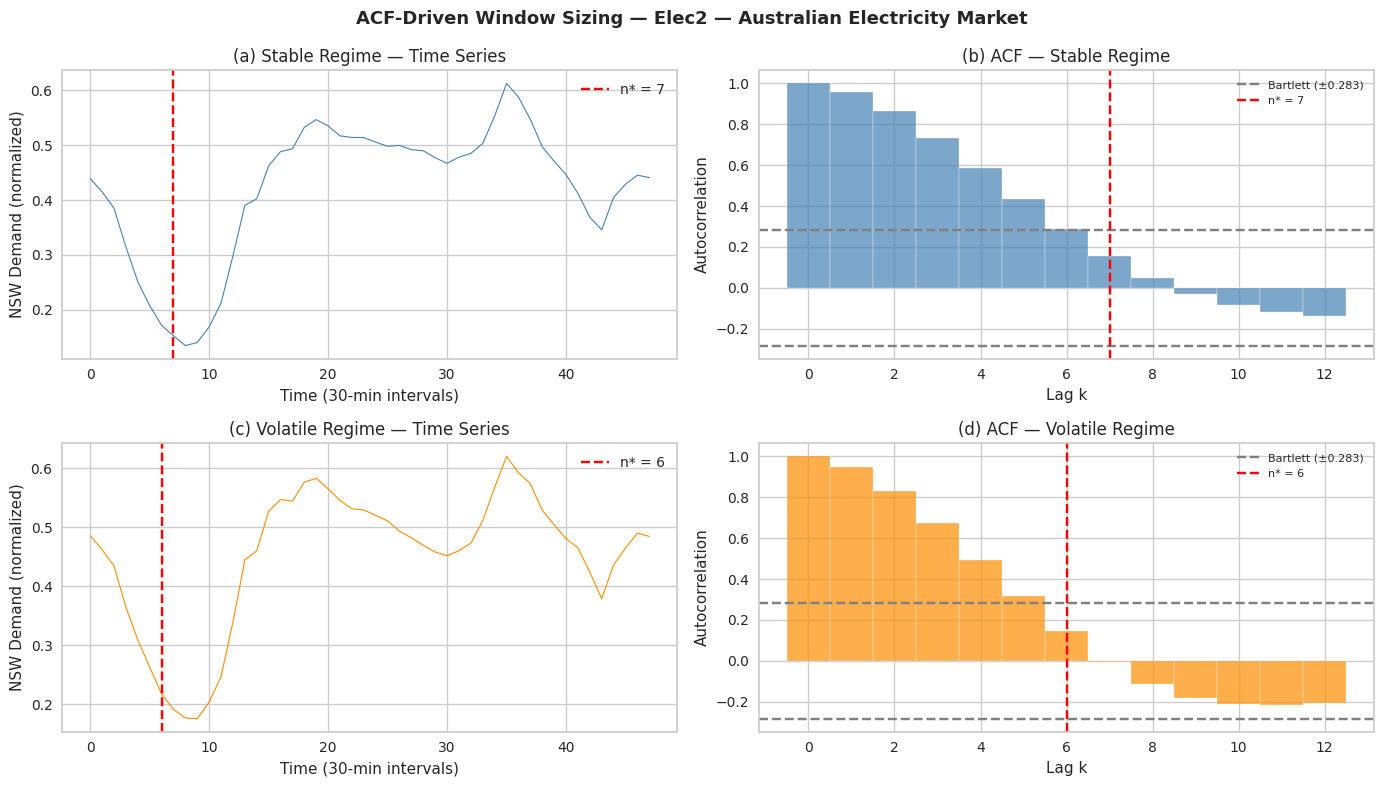

In [22]:
# --- Plot ACF profiles ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(stable_data, color='steelblue', linewidth=0.8)
axes[0, 0].axvline(x=n_stable, color='red', linestyle='--', label=f'n* = {n_stable}')
axes[0, 0].set_title('(a) Stable Regime — Time Series')
axes[0, 0].set_xlabel('Time (30-min intervals)')
axes[0, 0].set_ylabel('NSW Demand (normalized)')
axes[0, 0].legend()

axes[0, 1].bar(range(len(acf_stable)), acf_stable, color='steelblue', width=1.0, alpha=0.7)
axes[0, 1].axhline(y=bound_stable, color='gray', linestyle='--', label=f'Bartlett (±{bound_stable:.3f})')
axes[0, 1].axhline(y=-bound_stable, color='gray', linestyle='--')
axes[0, 1].axvline(x=n_stable, color='red', linestyle='--', label=f'n* = {n_stable}')
axes[0, 1].set_title('(b) ACF — Stable Regime')
axes[0, 1].set_xlabel('Lag k')
axes[0, 1].set_ylabel('Autocorrelation')
axes[0, 1].legend(fontsize=8)

axes[1, 0].plot(volatile_data, color='darkorange', linewidth=0.8)
axes[1, 0].axvline(x=n_volatile, color='red', linestyle='--', label=f'n* = {n_volatile}')
axes[1, 0].set_title('(c) Volatile Regime — Time Series')
axes[1, 0].set_xlabel('Time (30-min intervals)')
axes[1, 0].set_ylabel('NSW Demand (normalized)')
axes[1, 0].legend()

axes[1, 1].bar(range(len(acf_volatile)), acf_volatile, color='darkorange', width=1.0, alpha=0.7)
axes[1, 1].axhline(y=bound_volatile, color='gray', linestyle='--', label=f'Bartlett (±{bound_volatile:.3f})')
axes[1, 1].axhline(y=-bound_volatile, color='gray', linestyle='--')
axes[1, 1].axvline(x=n_volatile, color='red', linestyle='--', label=f'n* = {n_volatile}')
axes[1, 1].set_title('(d) ACF — Volatile Regime')
axes[1, 1].set_xlabel('Lag k')
axes[1, 1].set_ylabel('Autocorrelation')
axes[1, 1].legend(fontsize=8)

plt.suptitle(f'ACF-Driven Window Sizing — {DATASET_NAME}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 12. ACF-Based Structural Drift Detection

**Reference:** Section 3.3 (Eq. 8, 9, 10)

In [23]:
def acf_distance(window1, window2, max_lags=12):
    acf1 = acf(window1, nlags=max_lags, fft=True)[1:]
    acf2 = acf(window2, nlags=max_lags, fft=True)[1:]
    return np.sqrt(np.sum((acf1 - acf2) ** 2)), acf1, acf2

def acf_drift_threshold(n, L, alpha=0.05):
    chi2_val = chi2.ppf(1 - alpha, df=L)
    return np.sqrt((2 * L / n) * chi2_val)

target_series = newdf['target'].dropna().values
WINDOW_SIZE = DAY_SIZE
MAX_LAGS_DRIFT = 12
ALPHA = 0.05
NUM_WINDOWS = 10

print("ACF-Based Structural Drift Detection:")
print(f"Window size: {WINDOW_SIZE}, Max lags: {MAX_LAGS_DRIFT}, Alpha: {ALPHA}")
print()
print(f"{'Window Pair':<20} {'ACF Distance':>12} {'Threshold':>12} {'Drift?':>8}")
print("-" * 55)

drift_points = []

for i in range(NUM_WINDOWS - 1):
    w1_start = i * WINDOW_SIZE
    w2_end = (i + 2) * WINDOW_SIZE

    if w2_end > len(target_series):
        break

    w1 = target_series[w1_start:w1_start + WINDOW_SIZE]
    w2 = target_series[w1_start + WINDOW_SIZE:w2_end]

    d_acf, _, _ = acf_distance(w1, w2, MAX_LAGS_DRIFT)
    tau = acf_drift_threshold(WINDOW_SIZE, MAX_LAGS_DRIFT, ALPHA)

    is_drift = d_acf > tau
    if is_drift:
        drift_points.append(i + 1)

    print(f"W{i+1} vs W{i+2}          {d_acf:>12.4f} {tau:>12.4f} {'YES ⚠' if is_drift else 'NO':>8}")

print()
print(f"Total structural drifts detected: {len(drift_points)}")

ACF-Based Structural Drift Detection:
Window size: 48, Max lags: 12, Alpha: 0.05

Window Pair          ACF Distance    Threshold   Drift?
-------------------------------------------------------
W1 vs W2                0.0929       3.2424       NO
W2 vs W3                0.0524       3.2424       NO
W3 vs W4                0.2062       3.2424       NO
W4 vs W5                0.5590       3.2424       NO
W5 vs W6                0.8003       3.2424       NO
W6 vs W7                0.6324       3.2424       NO
W7 vs W8                0.5821       3.2424       NO
W8 vs W9                0.3662       3.2424       NO
W9 vs W10                0.3221       3.2424       NO

Total structural drifts detected: 0


---
## 13. Drift Visualization

**Reference:** Figure 7 in the paper

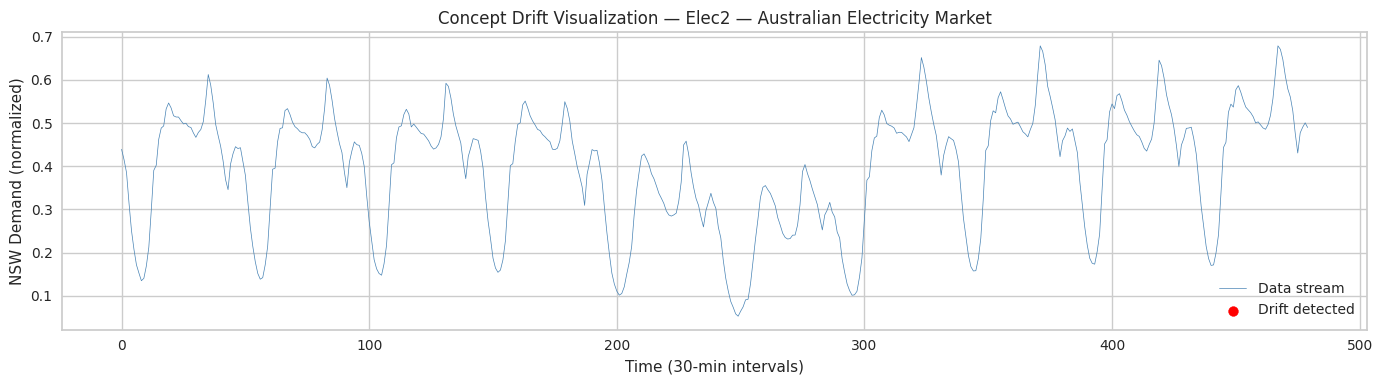

In [24]:
plot_length = NUM_WINDOWS * WINDOW_SIZE
plot_data = target_series[:plot_length]

plt.figure(figsize=(14, 4))
plt.plot(plot_data, color='steelblue', linewidth=0.5, label='Data stream')

for dp in drift_points:
    drift_idx = dp * WINDOW_SIZE
    plt.axvline(x=drift_idx, color='red', linestyle='--', alpha=0.5)
    plt.scatter(drift_idx, plot_data[drift_idx], color='red', s=50, zorder=5)

plt.scatter([], [], color='red', s=50, label='Drift detected')
plt.xlabel('Time (30-min intervals)')
plt.ylabel('NSW Demand (normalized)')
plt.title(f'Concept Drift Visualization — {DATASET_NAME}')
plt.legend()
plt.tight_layout()
plt.show()

---
## 14. Forecasting Performance Visualization

**Reference:** Figure 8 in the paper

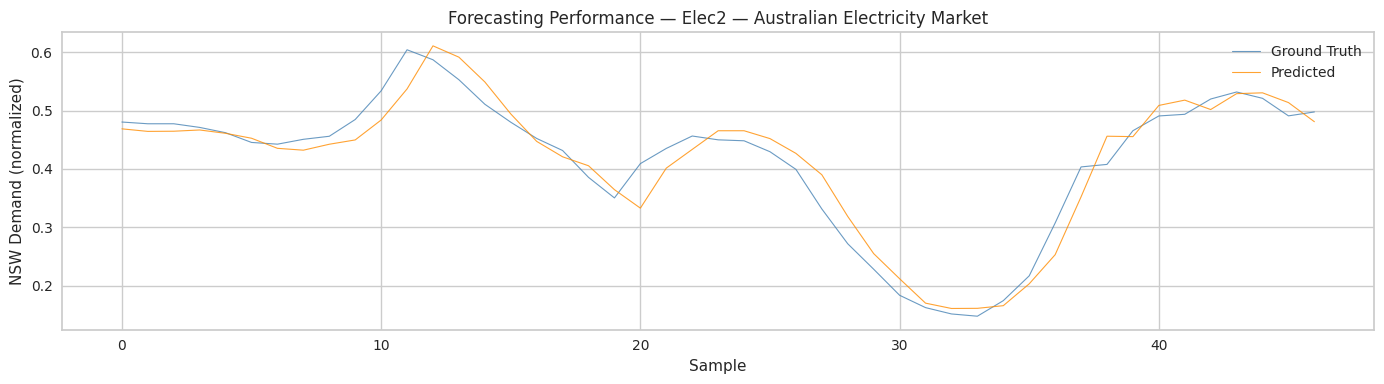

Streaming MAE:  0.023642
Streaming R²:   0.9363
Streaming MAPE: 0.0622


In [25]:
pred_df = pd.DataFrame(predictions_log)

plt.figure(figsize=(14, 4))
plt.plot(pred_df['actual'].values, color='steelblue', linewidth=0.8, label='Ground Truth', alpha=0.8)
plt.plot(pred_df['predicted'].values, color='darkorange', linewidth=0.8, label='Predicted', alpha=0.8)

for entry in adaptation_log:
    plt.axvline(x=entry['sample'], color='red', linestyle='--', alpha=0.4)

plt.xlabel('Sample')
plt.ylabel('NSW Demand (normalized)')
plt.title(f'Forecasting Performance — {DATASET_NAME}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Streaming MAE:  {mean_absolute_error(pred_df['actual'], pred_df['predicted']):.6f}")
print(f"Streaming R²:   {r2_score(pred_df['actual'], pred_df['predicted']):.4f}")
print(f"Streaming MAPE: {mean_absolute_percentage_error(pred_df['actual'], pred_df['predicted']):.4f}")

---
## 15. Fixed Window Comparison

**Reference:** Section 4.3.2 & Table 4

In [26]:
# --- Fixed window comparison ---
fixed_windows = [6, 12, 24, 36]
results = []

print("Evaluating fixed window sizes vs ACF-adaptive...")
print(f"{'Window':<15} {'MAE':>10} {'MSE':>12} {'R²':>8} {'MAPE':>8}")
print("-" * 56)

for ws in fixed_windows:
    reframed_ws = series_to_supervised(newdf.values, n_in=ws, n_out=1)
    target_col = f'var1(t-{ws})'

    train_data = reframed_ws.iloc[0:DAY_SIZE]

    s = setup(data=train_data, target=target_col, session_id=123, verbose=False)
    models_to_compare = ['et', 'xgboost', 'rf', 'gbr', 'huber']
    best = compare_models(include=models_to_compare, sort='MAE', fold=5, verbose=False)
    model = finalize_model(best)

    eval_data = reframed_ws.iloc[DAY_SIZE:DAY_SIZE*2]
    eval_X = eval_data.drop(columns=[target_col])
    eval_y = eval_data[target_col]
    preds = model.predict(eval_X)

    mae = mean_absolute_error(eval_y, preds)
    mse = mean_squared_error(eval_y, preds)
    r2 = r2_score(eval_y, preds)
    mape = mean_absolute_percentage_error(eval_y, preds)

    results.append({'window': f'Fixed-{ws}', 'mae': mae, 'mse': mse, 'r2': r2, 'mape': mape})
    print(f"Fixed-{ws:<9} {mae:>10.6f} {mse:>12.6f} {r2:>8.4f} {mape:>8.4f}")

# --- ACF-adaptive window ---
stable_data = newdf['target'].iloc[0:DAY_SIZE].dropna().values
acf_lags, _, _ = acf_window_size(stable_data)

reframed_acf = series_to_supervised(newdf.values, n_in=acf_lags, n_out=1)
target_col_acf = f'var1(t-{acf_lags})'

train_acf = reframed_acf.iloc[0:DAY_SIZE]
s = setup(data=train_acf, target=target_col_acf, session_id=123, verbose=False)
models_to_compare = ['et', 'xgboost', 'rf', 'gbr', 'huber']
best = compare_models(include=models_to_compare, sort='MAE', fold=5, verbose=False)
model_acf = finalize_model(best)

eval_acf = reframed_acf.iloc[DAY_SIZE:DAY_SIZE*2]
eval_X_acf = eval_acf.drop(columns=[target_col_acf])
eval_y_acf = eval_acf[target_col_acf]
preds_acf = model_acf.predict(eval_X_acf)

mae_acf = mean_absolute_error(eval_y_acf, preds_acf)
mse_acf = mean_squared_error(eval_y_acf, preds_acf)
r2_acf = r2_score(eval_y_acf, preds_acf)
mape_acf = mean_absolute_percentage_error(eval_y_acf, preds_acf)

results.append({'window': f'ACF(n*={acf_lags})', 'mae': mae_acf, 'mse': mse_acf, 'r2': r2_acf, 'mape': mape_acf})
print(f"ACF(n*={acf_lags}){'':<6} {mae_acf:>10.6f} {mse_acf:>12.6f} {r2_acf:>8.4f} {mape_acf:>8.4f}")

# --- ACF-MAAR ---
stream_mae = mean_absolute_error(pred_df['actual'], pred_df['predicted'])
stream_mse = mean_squared_error(pred_df['actual'], pred_df['predicted'])
stream_r2 = r2_score(pred_df['actual'], pred_df['predicted'])
stream_mape = mean_absolute_percentage_error(pred_df['actual'], pred_df['predicted'])

results.append({'window': 'ACF-MAAR', 'mae': stream_mae, 'mse': stream_mse, 'r2': stream_r2, 'mape': stream_mape})
print(f"{'ACF-MAAR':<15} {stream_mae:>10.6f} {stream_mse:>12.6f} {stream_r2:>8.4f} {stream_mape:>8.4f}")

results_df = pd.DataFrame(results)
print("\n")
print(results_df.to_string(index=False))

Evaluating fixed window sizes vs ACF-adaptive...
Window                 MAE          MSE       R²     MAPE
--------------------------------------------------------
Fixed-6           0.017676     0.000682   0.9512   0.0441
Fixed-12          0.014379     0.000347   0.9744   0.0362
Fixed-24          0.018715     0.000868   0.9357   0.0516
Fixed-36          0.012073     0.000460   0.9653   0.0288
ACF(n*=7)         0.017979     0.000697   0.9500   0.0450
ACF-MAAR          0.023642     0.000871   0.9363   0.0622


   window      mae      mse       r2     mape
  Fixed-6 0.017676 0.000682 0.951225 0.044077
 Fixed-12 0.014379 0.000347 0.974396 0.036200
 Fixed-24 0.018715 0.000868 0.935707 0.051594
 Fixed-36 0.012073 0.000460 0.965253 0.028764
ACF(n*=7) 0.017979 0.000697 0.949955 0.045026
 ACF-MAAR 0.023642 0.000871 0.936285 0.062179


---
## 16. Ablation Study

**Reference:** Section 4.7 & Table 12

In [27]:
# --- Ablation Study ---
from copy import deepcopy

def run_ablation_variant(reframed, newdf, variant_name, use_acf_window=True,
                          use_acf_drift=True, use_acf_trigger=True):

    if use_acf_window:
        stable_data = newdf['target'].iloc[0:DAY_SIZE].dropna().values
        n_lags, _, _ = acf_window_size(stable_data)
    else:
        n_lags = 12  # Fixed window for ablation

    reframed_abl = series_to_supervised(newdf.values, n_in=n_lags, n_out=1)
    target_col = f'var1(t-{n_lags})'

    train_data = reframed_abl.iloc[0:DAY_SIZE]
    s = setup(data=train_data, target=target_col, session_id=123, verbose=False)
    models_to_compare = ['et', 'xgboost', 'rf', 'gbr', 'huber']
    best = compare_models(include=models_to_compare, sort='MAE', fold=5, verbose=False)
    current_model = finalize_model(best)

    if use_acf_drift:
        ph = PageHinkley(min_instances=20, threshold=0.5)
        ad = ADWIN(delta=0.004)
        ks = KSWIN(alpha=0.001, window_size=48, stat_size=24)
        detectors = {"Page-Hinkley": ph, "ADWIN": ad, "KSWIN": ks}
    else:
        ad = ADWIN(delta=0.004)
        detectors = {"ADWIN": ad}

    threshold = ERROR_THRESHOLD if use_acf_trigger else ERROR_THRESHOLD * 0.5

    tier2_abl = 0
    predictions_abl = []

    START_IDX = DAY_SIZE
    stream_data = reframed_abl.iloc[START_IDX : START_IDX + DAY_SIZE]

    if len(stream_data) == 0:
        print(f"  WARNING: No streaming data for {variant_name}")
        return None, None, 0

    target_stream = stream_data[target_col].values.flatten()

    for j in range(1, min(DAY_SIZE, len(stream_data))):
        val = target_stream[j - 1]

        row = stream_data.iloc[j:j+1]
        row_X = row.drop(columns=[target_col])
        row_y = row[target_col].values[0]
        pred = current_model.predict(row_X)[0]
        predictions_abl.append({'actual': row_y, 'predicted': pred})

        for det_name, dd in detectors.items():
            dd.update(val)
            if dd.drift_detected:
                eval_chunk = reframed_abl.iloc[START_IDX : START_IDX + j]
                eval_X_chunk = eval_chunk.drop(columns=[target_col])
                eval_y_chunk = eval_chunk[target_col]
                chunk_pred = current_model.predict(eval_X_chunk)
                mae_check = mean_absolute_error(eval_y_chunk, chunk_pred)

                if mae_check > threshold:
                    tier2_abl += 1
                    retrain_start = max(0, START_IDX + j - DAY_SIZE)
                    retrain_data = reframed_abl.iloc[retrain_start : START_IDX + j]

                    s = setup(data=retrain_data, target=target_col,
                              session_id=123, verbose=False)
                    best = compare_models(include=models_to_compare, sort='MAE',
                                          fold=5, verbose=False)
                    current_model = finalize_model(best)

    pred_abl_df = pd.DataFrame(predictions_abl)
    abl_mae = mean_absolute_error(pred_abl_df['actual'], pred_abl_df['predicted'])
    abl_r2 = r2_score(pred_abl_df['actual'], pred_abl_df['predicted'])

    return abl_mae, abl_r2, tier2_abl


# === Run Ablation Study ===
print("=" * 68)
print(f"Ablation Study — {DATASET_NAME}")
print("=" * 68)
print(f"{'Configuration':<35} {'MAE':>10} {'R²':>8} {'Adaptations':>12}")
print("-" * 68)

print(f"{'Full ACF-MAAR':<35} {stream_mae:>10.6f} {stream_r2:>8.4f} {tier2_count:>12}")

print("\nRunning: Without ACF window (fixed=12)...")
mae_no_win, r2_no_win, t2_no_win = run_ablation_variant(
    reframed, newdf, "No ACF window",
    use_acf_window=False, use_acf_drift=True, use_acf_trigger=True
)
print(f"{'- ACF window (fixed 12)':<35} {mae_no_win:>10.6f} {r2_no_win:>8.4f} {t2_no_win:>12}")

print("\nRunning: Without ACF drift (ADWIN only)...")
mae_no_drift, r2_no_drift, t2_no_drift = run_ablation_variant(
    reframed, newdf, "No ACF drift",
    use_acf_window=True, use_acf_drift=False, use_acf_trigger=True
)
print(f"{'- ACF drift (ADWIN only)':<35} {mae_no_drift:>10.6f} {r2_no_drift:>8.4f} {t2_no_drift:>12}")

print("\nRunning: Without ACF trigger (fixed threshold)...")
mae_no_trig, r2_no_trig, t2_no_trig = run_ablation_variant(
    reframed, newdf, "No ACF trigger",
    use_acf_window=True, use_acf_drift=True, use_acf_trigger=False
)
print(f"{'- ACF trigger (fixed)':<35} {mae_no_trig:>10.6f} {r2_no_trig:>8.4f} {t2_no_trig:>12}")

print("\nRunning: Without all ACF (Fixed-MAAR)...")
mae_no_all, r2_no_all, t2_no_all = run_ablation_variant(
    reframed, newdf, "Fixed-MAAR",
    use_acf_window=False, use_acf_drift=False, use_acf_trigger=False
)
print(f"{'- All ACF (Fixed-MAAR)':<35} {mae_no_all:>10.6f} {r2_no_all:>8.4f} {t2_no_all:>12}")

# === Summary ===
print("\n" + "=" * 68)
print("Ablation Summary")
print("=" * 68)
print(f"{'Configuration':<35} {'MAE':>10} {'R²':>8} {'Adaptations':>12}")
print("-" * 68)
for name, mae_val, r2_val, adapt in [
    ("Full ACF-MAAR", stream_mae, stream_r2, tier2_count),
    ("- ACF window (fixed 12)", mae_no_win, r2_no_win, t2_no_win),
    ("- ACF drift (ADWIN only)", mae_no_drift, r2_no_drift, t2_no_drift),
    ("- ACF trigger (fixed)", mae_no_trig, r2_no_trig, t2_no_trig),
    ("- All ACF (Fixed-MAAR)", mae_no_all, r2_no_all, t2_no_all),
]:
    print(f"{name:<35} {mae_val:>10.6f} {r2_val:>8.4f} {adapt:>12}")
print("-" * 68)

Ablation Study — Elec2 — Australian Electricity Market
Configuration                              MAE       R²  Adaptations
--------------------------------------------------------------------
Full ACF-MAAR                         0.023642   0.9363            0

Running: Without ACF window (fixed=12)...
- ACF window (fixed 12)               0.014436   0.9741            0

Running: Without ACF drift (ADWIN only)...
- ACF drift (ADWIN only)              0.018114   0.9442            0

Running: Without ACF trigger (fixed threshold)...
- ACF trigger (fixed)                 0.018114   0.9442            0

Running: Without all ACF (Fixed-MAAR)...
- All ACF (Fixed-MAAR)                0.014436   0.9741            0

Ablation Summary
Configuration                              MAE       R²  Adaptations
--------------------------------------------------------------------
Full ACF-MAAR                         0.023642   0.9363            0
- ACF window (fixed 12)               0.014436   0.9741  